# Поиск статей справки Авито: TF-IDF baseline

## 1. Описание задачи и план решения

Для каждого пользовательского вопроса нужно вернуть до 10 наиболее подходящих `article_id`. Качество проверяется метрикой MAP@10: правильные статьи должны встречаться как можно выше в выдаче.

План:

1. загрузить и проверить реальные таблицы;
2. очистить HTML статей и одинаково нормализовать статьи и запросы;
3. сравнить word-level TF-IDF, character-level TF-IDF и их простую смесь;
4. выбрать метод только по `calibration.f`;
5. разобрать несколько удачных и неудачных примеров;
6. построить и автоматически проверить `output/answer.csv` для `test.f`.

Ограничения baseline: не используются нейросети, embeddings, CatBoost, внешние API и ручная разметка теста.

## 2. Импорты, настройки и фиксация `random_state`

Фиксируем seed, чтобы случайные операции при возможном расширении анализа были воспроизводимыми. Сам TF-IDF детерминирован.

In [18]:
from pathlib import Path
import random
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from bs4 import BeautifulSoup
from IPython.display import display
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_colwidth", 140)
plt.style.use("seaborn-v0_8-whitegrid")

DATA_DIR = Path("data")
OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)

## 3. Загрузка `articles.f`, `calibration.f` и `test.f`

Feather сохраняет типы таблиц и быстро читается через pandas. После загрузки сразу проверяем, что наборы колонок соответствуют задаче.

In [19]:
articles = pd.read_feather(DATA_DIR / "articles.f")
calibration = pd.read_feather(DATA_DIR / "calibration.f")
test = pd.read_feather(DATA_DIR / "test.f")

assert articles.columns.tolist() == ["article_id", "title", "body"]
assert calibration.columns.tolist() == ["query_id", "query_text", "ground_truth"]
assert test.columns.tolist() == ["query_id", "query_text"]

print("Данные успешно загружены.")

Данные успешно загружены.


## 4. Первичный анализ данных

Сначала посмотрим размеры, колонки, типы и пропуски. Это защищает от незаметных ошибок чтения и помогает оценить объём вычислений.

In [20]:
def table_summary(name, frame):
    return pd.DataFrame({
        "таблица": [name],
        "строк": [len(frame)],
        "колонок": [frame.shape[1]],
        "названия колонок": [", ".join(frame.columns)],
        "пропусков": [int(frame.isna().sum().sum())],
    })

display(pd.concat([
    table_summary("articles", articles),
    table_summary("calibration", calibration),
    table_summary("test", test),
], ignore_index=True))

for name, frame in [("articles", articles), ("calibration", calibration), ("test", test)]:
    print(f"\n{name}: типы данных")
    display(frame.dtypes.rename("dtype").to_frame())
    print("Пропуски по колонкам:")
    display(frame.isna().sum().rename("n_missing").to_frame())

,таблица,строк,колонок,названия колонок,пропусков
0,articles,793,3,"article_id, title, body",0
1,calibration,500,3,"query_id, query_text, ground_truth",0
2,test,500,2,"query_id, query_text",0



articles: типы данных


,dtype
article_id,int64
title,string[python]
body,string[python]


Пропуски по колонкам:


,n_missing
article_id,0
title,0
body,0


...

,n_missing
query_id,0
query_text,0
ground_truth,0



test: типы данных


,dtype
query_id,int64
query_text,string[python]


Пропуски по колонкам:


,n_missing
query_id,0
query_text,0


Идентификаторы должны быть уникальными: иначе одна статья или один запрос могли бы несколько раз попасть в расчёт и исказить метрику.

In [21]:
duplicate_checks = pd.DataFrame({
    "проверка": [
        "article_id в articles",
        "query_id в calibration",
        "query_id в test",
    ],
    "число дублей": [
        articles["article_id"].duplicated().sum(),
        calibration["query_id"].duplicated().sum(),
        test["query_id"].duplicated().sum(),
    ],
})
display(duplicate_checks)

,проверка,число дублей
0,article_id в articles,0
1,query_id в calibration,0
2,query_id в test,0


Посмотрим несколько примеров. HTML пока не очищаем специально: так видно, с какой исходной разметкой предстоит работать.

In [22]:
display(articles[["article_id", "title", "body"]].head(3))
display(calibration[["query_id", "query_text", "ground_truth"]].head(5))
display(test[["query_id", "query_text"]].head(5))

,article_id,title,body
0,1730,Имя или название компании,"<ol><li><p>Зайдите в раздел <a href=""https://www.avito.ru/profile/extended"">Управление профилем</a>.</p><ol start=""2""><li><p>Нажмите <st..."
1,1746,"Понять, что профиль заблокирован","<p>Проверьте, какое сообщение вы видите при входе в профиль.</p><div class=""tabset tabset_155""><input type=""radio"" name=""tab_radio_155"" ..."
2,1747,Не допустить блокировки профиля,"<ol><li><p><strong>Не заводите несколько аккаунтов для продаж в одной категории. </strong>Так поступают пользователи, которые хотят обой..."


,query_id,query_text,ground_truth
0,1,Как передать товар через службу авито,1909 4234
1,2,"Можете подсказать, если заказать товар Авито доставкой и оплатить также через авито, в случае возврата товара деньги безусловно мне возв...",2865 4400
2,3,Здравствуйте. Как отправить товар через Авито.,1909
3,4,как получить деньги за возрат если продавец уже забрал товар?,4400 4403
4,5,"Когда мне прийдут деньги за доставку, сегодня уже <DATE>",4361


,query_id,query_text
0,1,"Здравствуйте! Подскажите, пожалуйста, не могу оформить доставку , какие-то проблемы с приложением?"
1,2,"Здравствуйте , почему так долго доставляется возврат? В приложении СДЭКА пишет то что посылка вручена, а на Авито до сих пор то что зака..."
2,3,"Здравствуйте,подскажите как мне отправить кроссовки покупателю через пункт «Авито»?"
3,4,Здравствуйте! В каких случаях за возврат снимают деньги за доставку у покупателя?
4,5,Почему у меня доставки в несколько раз дороже с данного аккаунта чем с другого на одни и те же товары


Один запрос может иметь несколько правильных статей. Разделим `ground_truth` по пробелам и изучим это распределение.

,запросов
правильных статей,
1,279
2,182
3,38
4,1


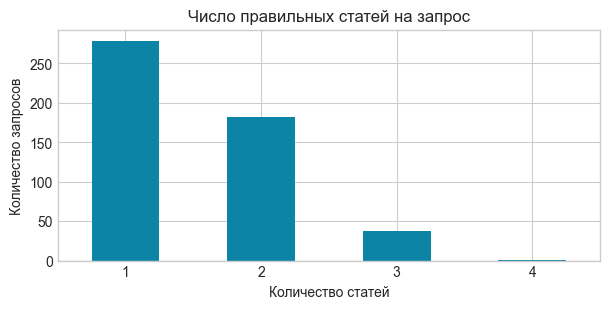

In [23]:
calibration["relevant_ids"] = calibration["ground_truth"].map(
    lambda value: [int(article_id) for article_id in value.split()]
)
calibration["n_relevant"] = calibration["relevant_ids"].str.len()

gt_distribution = (
    calibration["n_relevant"].value_counts().sort_index().rename_axis("правильных статей").rename("запросов")
)
display(gt_distribution.to_frame())

ax = gt_distribution.plot.bar(figsize=(7, 3), color="#0b84a5", rot=0)
ax.set(title="Число правильных статей на запрос", xlabel="Количество статей", ylabel="Количество запросов")
plt.show()

### Длины текстов

Для запросов и заголовков считаем слова. Для тела статьи длину в словах корректнее измерить после удаления HTML — эту часть выполним сразу после создания функции очистки.

In [24]:
calibration["query_words"] = calibration["query_text"].str.split().str.len()
test["query_words"] = test["query_text"].str.split().str.len()
articles["title_words"] = articles["title"].str.split().str.len()

lengths_before_html = pd.DataFrame({
    "calibration: слова в запросе": calibration["query_words"].describe(),
    "test: слова в запросе": test["query_words"].describe(),
    "статьи: слова в заголовке": articles["title_words"].describe(),
}).round(2)
display(lengths_before_html)

,calibration: слова в запросе,test: слова в запросе,статьи: слова в заголовке
count,500.00,500.00,793.00
mean,11.61,11.76,4.04
std,5.39,6.51,2.02
min,2.00,2.00,1.00
25%,7.00,7.00,3.00
50%,10.00,10.00,4.00
75%,15.00,15.00,5.00
max,28.00,43.00,17.00


## 5. Предварительная обработка

`BeautifulSoup` разбирает даже неидеальный HTML безопаснее регулярных выражений. Удаляем `script`, `style`, `noscript`, `template` и `svg`, но оставляем видимое содержимое абзацев, списков и таблиц. `get_text` удаляет служебные теги, сохраняя их текст.

Затем единая функция нормализации:

- приводит текст к нижнему регистру;
- заменяет `ё` на `е`, чтобы варианты написания совпадали;
- сжимает повторяющиеся пробелы.

Эта же функция применяется к заголовкам, телам статей и запросам.

In [25]:
def normalize_text(text):
    'Единая нормализация текста статьи или запроса.'
    text = str(text).lower().replace("ё", "е")
    return re.sub(r"\s+", " ", text).strip()


def html_to_visible_text(html):
    'Извлекает видимый текст, включая списки и таблицы, без служебных тегов.'
    soup = BeautifulSoup(str(html), "html.parser")
    for tag in soup(["script", "style", "noscript", "template", "svg"]):
        tag.decompose()
    return normalize_text(soup.get_text(" ", strip=True))


# Небольшая автоматическая проверка важных свойств очистки.
example_html = "<style>x</style><p>Ёлка</p><ul><li>Пункт</li></ul><table><tr><td>Ячейка</td></tr></table><script>bad</script>"
assert html_to_visible_text(example_html) == "елка пункт ячейка"

articles["title_clean"] = articles["title"].map(normalize_text)
articles["body_clean"] = articles["body"].map(html_to_visible_text)
articles["search_text"] = articles["title_clean"] + " " + articles["body_clean"]
calibration["query_clean"] = calibration["query_text"].map(normalize_text)
test["query_clean"] = test["query_text"].map(normalize_text)

display(articles[["article_id", "title_clean", "body_clean"]].head(3))

,article_id,title_clean,body_clean
0,1730,имя или название компании,зайдите в раздел управление профилем . нажмите на карандашик в правом верхнем углу. введите новое имя или название и нажмите сохранить ....
1,1746,"понять, что профиль заблокирован","проверьте, какое сообщение вы видите при входе в профиль. профиль заблокирован доступ к профилю ограничен доступ ограничен. пройдите про..."
2,1747,не допустить блокировки профиля,"не заводите несколько аккаунтов для продаж в одной категории. так поступают пользователи, которые хотят обойти наши правила, — то есть п..."


Теперь сравним длины очищенных тел статей и запросов. Очень длинные статьи могут содержать много общих слов — TF-IDF частично компенсирует это нормировкой векторов.

,запросы calibration,заголовки статей,тексты статей
count,500.00,793.00,793.00
mean,11.61,4.04,740.99
std,5.39,2.02,2394.31
min,2.00,1.00,3.00
25%,7.00,3.00,172.00
50%,10.00,4.00,333.00
75%,15.00,5.00,706.00
max,28.00,17.00,61797.00


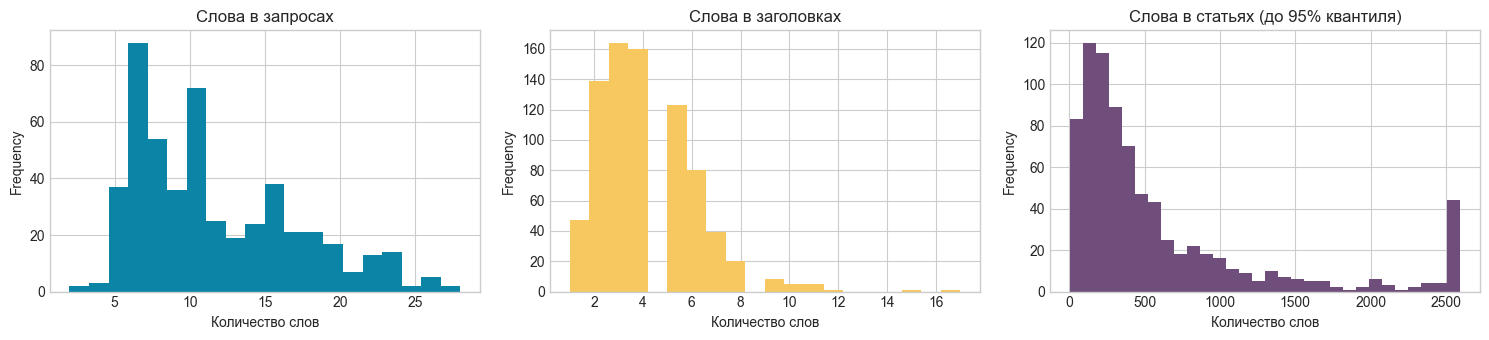

In [26]:
articles["body_words"] = articles["body_clean"].str.split().str.len()

display(pd.DataFrame({
    "запросы calibration": calibration["query_clean"].str.split().str.len().describe(),
    "заголовки статей": articles["title_clean"].str.split().str.len().describe(),
    "тексты статей": articles["body_words"].describe(),
}).round(2))

fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
calibration["query_clean"].str.split().str.len().plot.hist(bins=20, ax=axes[0], color="#0b84a5")
articles["title_clean"].str.split().str.len().plot.hist(bins=20, ax=axes[1], color="#f6c85f")
articles["body_words"].clip(upper=articles["body_words"].quantile(0.95)).plot.hist(
    bins=30, ax=axes[2], color="#6f4e7c"
)
axes[0].set_title("Слова в запросах")
axes[1].set_title("Слова в заголовках")
axes[2].set_title("Слова в статьях (до 95% квантиля)")
for ax in axes:
    ax.set_xlabel("Количество слов")
plt.tight_layout()
plt.show()

### Краткие выводы по анализу

- корпус небольшой: 793 статьи, поэтому можно сравнить каждый запрос со всеми документами;
- в `articles`, `calibration` и `test` нет пропусков и дублей ключевых идентификаторов;
- calibration и test содержат по 500 запросов и сопоставимы по длине;
- у большинства calibration-запросов одна или две правильные статьи, поэтому важно ранжирование не только первого документа;
- запросы и заголовки короткие, а тела статей заметно длиннее и содержат HTML; сочетание словных и символьных признаков должно быть полезно при опечатках и разных формах слов.

## 6. Реализация метрик AP@10 и MAP@10

AP@10 накапливает precision на позициях, где найдена новая релевантная статья, и делит сумму на число релевантных статей (не больше 10). MAP@10 — среднее AP@10 по запросам. Повтор в предсказании не засчитывается второй раз.

In [27]:
def average_precision_at_k(predicted, relevant, k=10):
    relevant = set(relevant)
    if not relevant:
        return 0.0

    hits = 0
    score = 0.0
    seen = set()
    for rank, article_id in enumerate(predicted[:k], start=1):
        if article_id in relevant and article_id not in seen:
            hits += 1
            score += hits / rank
        seen.add(article_id)
    return score / min(len(relevant), k)


def mean_average_precision_at_k(predictions, ground_truth, k=10):
    return float(np.mean([
        average_precision_at_k(predicted, relevant, k)
        for predicted, relevant in zip(predictions, ground_truth)
    ]))


# Проверяем идеальный порядок, перестановку и защиту от повторов.
assert average_precision_at_k([1, 2, 3], [1, 2]) == 1.0
assert np.isclose(average_precision_at_k([3, 1, 2], [1, 2]), (1 / 2 + 2 / 3) / 2)
assert average_precision_at_k([1, 1, 2], [1, 2]) < 1.0
print("Проверки AP@10 пройдены.")

Проверки AP@10 пройдены.


## 7. Baseline-методы: word, character и гибрид

Word-level TF-IDF использует униграммы и биграммы: они хорошо ловят точные слова и короткие выражения. Character-level TF-IDF с `char_wb` строит символьные n-граммы внутри границ слов: он устойчивее к опечаткам и окончаниям.

Векторизаторы обучаются только на статьях. Размеченные запросы из `calibration.f` фиксированно делим на 70% для выбора метода и 30% для честной локальной проверки. Стратификация сохраняет соотношение запросов с одной, двумя и тремя или более правильными статьями. `test.f` в настройке и оценке не используется. Все векторы L2-нормированы самим `TfidfVectorizer`, поэтому скалярное произведение равно cosine similarity.

In [28]:
article_ids = articles["article_id"].to_numpy()
calibration_truth = calibration["relevant_ids"].tolist()

# Редкую категорию с 4 статьями объединяем с категорией 3+ для стратификации.
selection_indices, holdout_indices = train_test_split(
    np.arange(len(calibration)),
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=calibration["n_relevant"].clip(upper=3),
)
assert len(selection_indices) == 350 and len(holdout_indices) == 150
assert set(selection_indices).isdisjoint(holdout_indices)
print(f"Выбор метода: {len(selection_indices)} запросов; локальный тест: {len(holdout_indices)} запросов")

word_vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=1,
    max_df=0.98,
    sublinear_tf=True,
    max_features=150_000,
    dtype=np.float32,
)
char_vectorizer = TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=(3, 5),
    min_df=2,
    sublinear_tf=True,
    max_features=200_000,
    dtype=np.float32,
)

word_articles = word_vectorizer.fit_transform(articles["search_text"])
char_articles = char_vectorizer.fit_transform(articles["search_text"])
word_calibration = word_vectorizer.transform(calibration["query_clean"])
char_calibration = char_vectorizer.transform(calibration["query_clean"])

word_scores = (word_calibration @ word_articles.T).toarray()
char_scores = (char_calibration @ char_articles.T).toarray()

print("Word-матрица статей:", word_articles.shape)
print("Character-матрица статей:", char_articles.shape)

Выбор метода: 350 запросов; локальный тест: 150 запросов
Word-матрица статей: (793, 150000)
Character-матрица статей: (793, 70049)


Функция ранжирования сортирует документы по убыванию similarity и возвращает до 10 уникальных `article_id`. Уникальность дополнительно обеспечивается явно, хотя в исходной таблице дублей `article_id` нет.

In [29]:
def rank_articles(score_matrix, ids, k=10):
    rankings = []
    for row in score_matrix:
        order = np.argsort(-row, kind="stable")
        unique_ids = []
        seen = set()
        for index in order:
            article_id = int(ids[index])
            if article_id not in seen:
                unique_ids.append(article_id)
                seen.add(article_id)
            if len(unique_ids) == k:
                break
        rankings.append(unique_ids)
    return rankings


calibration_predictions = {
    "word TF-IDF": rank_articles(word_scores, article_ids),
    "character TF-IDF": rank_articles(char_scores, article_ids),
}

# Проверяем только три заранее заданных веса word-компоненты.
HYBRID_WEIGHTS = [0.25, 0.50, 0.75]
for word_weight in HYBRID_WEIGHTS:
    name = f"hybrid: {word_weight:.2f} word + {1 - word_weight:.2f} char"
    hybrid_scores = word_weight * word_scores + (1 - word_weight) * char_scores
    calibration_predictions[name] = rank_articles(hybrid_scores, article_ids)

Сначала сравниваем методы по MAP@10 на 70% `calibration.f` и выбираем победителя только по этой колонке. MAP@10 на отложенных 30% показываем как итоговую локальную оценку, но не используем для выбора. Запросы из `test.f` нигде в настройке не участвуют.

In [30]:
def map_on_indices(predictions, indices):
    return mean_average_precision_at_k(
        [predictions[index] for index in indices],
        [calibration_truth[index] for index in indices],
    )


comparison = pd.DataFrame([
    {
        "method": method,
        "MAP@10 — выбор (70%)": map_on_indices(predictions, selection_indices),
        "MAP@10 — локальный тест (30%)": map_on_indices(predictions, holdout_indices),
    }
    for method, predictions in calibration_predictions.items()
]).sort_values("MAP@10 — выбор (70%)", ascending=False, ignore_index=True)

best_method = comparison.loc[0, "method"]
selection_map10 = float(comparison.loc[0, "MAP@10 — выбор (70%)"])
best_map10 = float(comparison.loc[0, "MAP@10 — локальный тест (30%)"])
best_predictions = calibration_predictions[best_method]

display(comparison.style.format({
    "MAP@10 — выбор (70%)": "{:.6f}",
    "MAP@10 — локальный тест (30%)": "{:.6f}",
}))
print(f"Выбранный метод: {best_method}")
print(f"MAP@10 на 70% для выбора: {selection_map10:.6f}")
print(f"Итоговый MAP@10 на отложенных 30%: {best_map10:.6f}")

,method,MAP@10 — выбор (70%),MAP@10 — локальный тест (30%)
0,hybrid: 0.75 word + 0.25 char,0.243885,0.251429
1,hybrid: 0.50 word + 0.50 char,0.241070,0.248200
2,hybrid: 0.25 word + 0.75 char,0.230373,0.237952
3,word TF-IDF,0.207065,0.223489
4,character TF-IDF,0.204314,0.222193


Выбранный метод: hybrid: 0.75 word + 0.25 char
MAP@10 на 70% для выбора: 0.243885
Итоговый MAP@10 на отложенных 30%: 0.251429


## 8. Небольшой анализ ошибок

Для каждого запроса из отложенных 30% считаем AP@10. Показываем несколько лучших и худших случаев без ручного выбора `query_id`: примеры определяются метрикой автоматически. В таблице есть правильные и найденные статьи, их заголовки и позиции релевантных документов.

In [31]:
title_by_id = articles.set_index("article_id")["title"].to_dict()
calibration_analysis = calibration.iloc[holdout_indices][["query_id", "query_text", "relevant_ids"]].copy()
calibration_analysis["predicted_ids"] = [best_predictions[index] for index in holdout_indices]
calibration_analysis["AP@10"] = [
    average_precision_at_k(predicted, relevant)
    for predicted, relevant in zip(calibration_analysis["predicted_ids"], calibration_analysis["relevant_ids"])
]


def describe_query(row):
    relevant = row["relevant_ids"]
    predicted = row["predicted_ids"]
    positions = {
        article_id: (predicted.index(article_id) + 1 if article_id in predicted else "не найдено в top-10")
        for article_id in relevant
    }
    return {
        "query_id": row["query_id"],
        "AP@10": row["AP@10"],
        "запрос": row["query_text"],
        "правильные статьи": [(article_id, title_by_id[article_id]) for article_id in relevant],
        "позиции правильных": positions,
        "top-10 найденных": [(article_id, title_by_id[article_id]) for article_id in predicted],
    }


successful = calibration_analysis.sort_values(["AP@10", "query_id"], ascending=[False, True]).head(3)
unsuccessful = calibration_analysis.sort_values(["AP@10", "query_id"], ascending=[True, True]).head(3)

print("Успешные примеры")
display(pd.DataFrame([describe_query(row) for _, row in successful.iterrows()]))
print("Неуспешные примеры")
display(pd.DataFrame([describe_query(row) for _, row in unsuccessful.iterrows()]))

Успешные примеры


,query_id,AP@10,запрос,правильные статьи,позиции правильных,top-10 найденных
0,8,1.0,"Добрый вечер , выбираю способ оплаты при получении , для это выбираю почту России , а графа оплата при получении горит красным , что не ...","[(2646, Оплата заказов с доставкой), (4219, Покупателю)]","{2646: 1, 4219: 2}","[(2646, Оплата заказов с доставкой), (4219, Покупателю), (2831, Приехал повреждённый товар), (4403, Продавцу — товар не забирают или вер..."
1,18,1.0,"Здравствуйте, почему сумма доставки меняется при оформлении?","[(1951, Кто оплачивает доставку и сколько она стоит)]",{1951: 1},"[(1951, Кто оплачивает доставку и сколько она стоит), (2802, Заказ не движется), (4219, Покупателю), (3843, Заказ потерялся: что делать?..."
2,28,1.0,"Добрый день! Подскажите, не вижу объект в черновиках у сотрудника (Галина Светлая). В чем может быть проблема?","[(2661, Не вижу объявление в профиле)]",{2661: 1},"[(2661, Не вижу объявление в профиле), (2794, Не вижу своё объявление), (2663, Не вижу объявление в поиске), (4526, Рекламным агентствам..."


Неуспешные примеры


,query_id,AP@10,запрос,правильные статьи,позиции правильных,top-10 найденных
0,7,0.0,Почему такая Большая сумма доставки из Москлвской области в Казань?,"[(1951, Кто оплачивает доставку и сколько она стоит)]",{1951: 'не найдено в top-10'},"[(1899, В каких городах есть доставка), (1985, Искать в других регионах), (3265, Указано, что для товара нет Авито Доставки), (3236, Спи..."
1,16,0.0,"продавец отменил заказ, когда приедут деньги?","[(4219, Покупателю)]",{4219: 'не найдено в top-10'},"[(3132, Изменили этап сделки), (4504, Цифровые продукты: информация для покупателей), (1958, Продавец не отправляет заказ), (4446, Покуп..."
2,26,0.0,Добрый вечер. Покупатель задает вопрос. Типа не настроено что-то для крупной посылки,"[(4234, Как продавать и покупать с доставкой)]",{4234: 'не найдено в top-10'},"[(4428, Работа), (2831, Приехал повреждённый товар), (3148, Ассистент для продавцов и покупателей), (4507, Частые вопросы), (1837, Ответ..."


### Выводы из ошибок

TF-IDF хорошо работает, когда запрос и статья используют одинаковые предметные слова. Ошибки чаще возникают, когда:

- пользователь описывает ситуацию разговорно, а в статье используется другая терминология;
- нескольким статьям соответствуют похожие слова, но разные условия или этапы процесса;
- нужная информация находится в длинной статье и её сигнал размывается общим текстом;
- релевантность определяется смыслом, который нельзя надёжно восстановить только по совпадениям слов и символов.

Это ожидаемый потолок интерпретируемого baseline. В первой версии мы не добавляем сложные модели, чтобы сохранить честную и воспроизводимую точку отсчёта.

## 9. Обучение лучшего метода и создание `output/answer.csv`

Векторизаторы уже обучены только на корпусе статей. Преобразуем тестовые запросы и применим тот же метод/вес, который был выбран на обучающих 70% `calibration.f`. Отложенные 30% использовались только для локальной оценки.

In [32]:
word_test = word_vectorizer.transform(test["query_clean"])
char_test = char_vectorizer.transform(test["query_clean"])
test_word_scores = (word_test @ word_articles.T).toarray()
test_char_scores = (char_test @ char_articles.T).toarray()

if best_method == "word TF-IDF":
    test_scores = test_word_scores
elif best_method == "character TF-IDF":
    test_scores = test_char_scores
else:
    best_word_weight = float(re.search(r"hybrid: ([0-9.]+)", best_method).group(1))
    test_scores = best_word_weight * test_word_scores + (1 - best_word_weight) * test_char_scores

test_predictions = rank_articles(test_scores, article_ids, k=10)
answer = test[["query_id"]].copy()
answer["answer"] = [" ".join(map(str, prediction)) for prediction in test_predictions]
answer_path = OUTPUT_DIR / "answer.csv"
answer.to_csv(answer_path, index=False)

display(answer.head())
print("Файл сохранён:", answer_path)

,query_id,answer
0,1,1899 3565 4057 3056 4308 4386 2923 1901 4394 3595
1,2,2802 2521 3149 3843 4009 3168 2944 1923 4205 3006
2,3,4503 1918 4403 3888 3895 1960 2065 2919 3870 3419
3,4,3149 2943 2865 2866 2696 3006 3748 1775 4331 4400
4,5,3006 2698 3128 4214 3168 3265 4294 1901 3594 4258


Файл сохранён: output/answer.csv


## 10. Автоматическая проверка итогового файла

Перед завершением заново читаем CSV с диска и проверяем все требования формата: строки, колонки, пропуски, длину ответов, повторы, существование статей и исходный порядок `query_id`.

In [33]:
saved_answer = pd.read_csv(answer_path, dtype={"query_id": test["query_id"].dtype, "answer": "string"})
known_article_ids = set(articles["article_id"].astype(int))
parsed_answers = saved_answer["answer"].map(lambda value: [int(item) for item in value.split()])

assert len(saved_answer) == len(test), "Число строк не совпадает с test.f"
assert saved_answer.columns.tolist() == ["query_id", "answer"], "Неверные названия или порядок колонок"
assert not saved_answer.isna().any().any(), "В ответе есть пропуски"
assert parsed_answers.map(len).between(1, 10).all(), "Ответ должен содержать от 1 до 10 id"
assert parsed_answers.map(lambda ids: len(ids) == len(set(ids))).all(), "Внутри ответа есть повторы"
assert parsed_answers.map(lambda ids: set(ids).issubset(known_article_ids)).all(), "Найден неизвестный article_id"
assert saved_answer["query_id"].tolist() == test["query_id"].tolist(), "Нарушен порядок query_id"

print(f"Все проверки пройдены: {len(saved_answer)} строк, файл {answer_path}")
print(f"Итоговый локальный результат на отложенных 30%: MAP@10 = {best_map10:.6f}")

Все проверки пройдены: 500 строк, файл output/answer.csv
Итоговый локальный результат на отложенных 30%: MAP@10 = 0.251429
